# O1 - Does modeling the protein improve RBP-binding prediction? (in-distribution, leakage-controlled)
**Milestone 1** (binary: binds / doesn't) and **Milestone 2** (continuous per-nucleotide binding signal). We ask two questions, rigorously: **(Q1)** does conditioning a frozen RNA model (PARNET) on a protein representation beat what the RNA alone already predicts? **(Q2)** is any cross-attention / multitask advantage a *real* architectural gain, or just better optimization?

*Scope: in-distribution (held-out chromosomes/windows, RBPs seen in training). Zero-shot to unseen RBP families is treated separately (it does not hold up, see the S/PB series). All numbers from committed `mmpartnet_out/` results computed on a CUDA GPU on the ENCODE eCLIP data.*

## Background (regulatory genomics)
RNA-binding proteins (RBPs) bind mRNAs to control **splicing, stability, localization and translation** -- the post-transcriptional layer of gene regulation, and a growing therapeutic target space. **eCLIP** maps, per nucleotide, where an RBP crosslinks to RNA (a target track + a size-matched input control); **PARNET / RBPNet** learn to predict this crosslink profile from RNA sequence alone via a dilated convolutional body + an additive target/control mixture head (a MultinomialNLL over the window).

Most such models use **only RNA sequence** and ignore *which* RBP. Our question is whether adding an explicit **protein representation** (ESM-2 / ProtT5 over the RBP) improves prediction. We keep the PARNET body **frozen** (transfer learning) and train only a small conditioning head:
- **concat** -- concatenate [protein, pooled RNA features] -> MLP (the baseline fusion),
- **FiLM** -- protein generates per-feature scale/shift (gamma, beta) on the RNA features,
- **cross-attention (xattn)** -- protein tokens attend to RNA positions (TFBindFormer-style),
- **per-residue (perres)** -- per-RNA-position cross-attention to the protein (nt-resolution).

## Definitions and controls (the math)
**M1 metric -- AUPRC** per RBP (positives are bound windows; class-imbalanced, so AUPRC not AUROC).

**M2 metric -- profile Pearson**: correlation between predicted and observed per-nt crosslink profile within a window, $r(\hat p, p)$.

A protein-conditioned score is only meaningful against **controls that remove exactly the thing we claim**:
- **RNA-only baseline** (track-aware, equal budget, protein *absent*): the bar the protein must beat. $\text{gap}_{\text{RNA}} = \text{method} - \text{RNA-only}$.
- **Protein-shuffle null** (derange the protein rep across RBPs): if a method beats this, it is using protein *identity*. $\text{gap}_{\text{shuf}} = \text{method} - \text{shuffle}$.
- **Random-body control** (frozen randomly-initialised body): the RNA-only baseline minus this = the share of the baseline attributable to **PARNET pretraining leakage** ($\Delta_{\text{leak}}$).
- **Fair optimization**: each mechanism is tuned to its own best learning rate before comparison, so a gap reflects the architecture, not the optimizer (Q2).

In [1]:
import json, math
from pathlib import Path
import numpy as np, matplotlib
matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
OUT = Path('..')/'..'/'mmpartnet_out'
def J(n): return json.loads((OUT/n).read_text(encoding='utf-8'))
bf=J('binding_fair.json'); bm=J('binding_mechanism.json'); mp=J('m2_profile.json')
mz=J('m2_profile_zeroshot_hepg2.json'); xf=J('xattn_faithfulness.json')
print('M1 panel:', bf['K'], 'RBPs;', bf['n_train'],'train /',bf['n_test'],'test windows; parnet_body=',bf['parnet_body'])

M1 panel: 68 RBPs; 25000 train / 15000 test windows; parnet_body= all-223 (LEAKED, in-distribution)


## Q1a - M1: does the protein help *binary* binding?
Each conditioning head, per RBP, vs the RNA-only baseline and vs its own protein-shuffle.

In [2]:
base=bf['baselines']; leak=bf['leakage_attributable_auprc']
order=['concat','film','xattn','perres']
tab='| method | AUPRC (real) | gap vs shuffle [95% CI] | gap vs RNA-only [95% CI] | #beat RNA-only / N | vs RNA-only |\n|---|---|---|---|---|---|\n'
for m in order:
    d=bf['methods'][m]; cs=d['gap_vs_shuffle_ci']; cr=d['gap_vs_rna_only_ci']
    tab+=f"| {m} | {d['real']:.3f} | {d['gap_vs_shuffle']:+.3f} [{cs[0]:+.3f},{cs[1]:+.3f}] | {d['gap_vs_rna_only']:+.3f} [{cr[0]:+.3f},{cr[1]:+.3f}] | {d['n_beat_rna_only']}/{d['n_rbp']} | {d['direction_vs_rna_only']} |\n"
display(Markdown(tab))
display(Markdown(f"**RNA-only baselines (AUPRC):** track-aware {base['rna_only_multitask']:.3f}, random-body {base['rna_only_randombody']:.3f}, "
  f"bindability {base['rna_only_bindability']:.3f}. **Leakage-attributable = {leak:.3f}** (PARNET-pretraining share of the RNA-only bar)."))

| method | AUPRC (real) | gap vs shuffle [95% CI] | gap vs RNA-only [95% CI] | #beat RNA-only / N | vs RNA-only |
|---|---|---|---|---|---|
| concat | 0.085 | +0.047 [+0.034,+0.063] | -0.021 [-0.028,-0.016] | 5/68 | UNDERPERFORMS |
| film | 0.104 | +0.066 [+0.048,+0.086] | -0.002 [-0.004,-0.000] | 22/68 | UNDERPERFORMS |
| xattn | 0.116 | +0.078 [+0.056,+0.102] | +0.010 [+0.004,+0.018] | 35/68 | BEATS |
| perres | 0.121 | +0.083 [+0.059,+0.108] | +0.015 [+0.009,+0.023] | 43/68 | BEATS |


**RNA-only baselines (AUPRC):** track-aware 0.106, random-body 0.057, bindability 0.033. **Leakage-attributable = 0.049** (PARNET-pretraining share of the RNA-only bar).

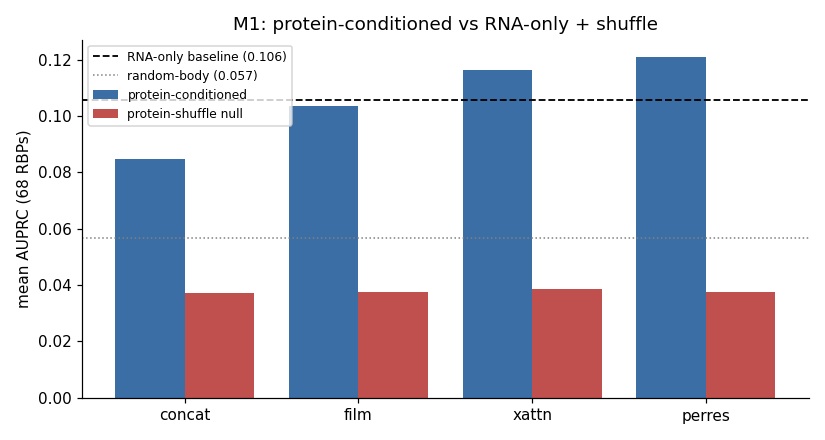

In [3]:
fig,ax=plt.subplots(figsize=(7.5,4))
x=np.arange(len(order)); real=[bf['methods'][m]['real'] for m in order]; shuf=[bf['methods'][m]['shuffle'] for m in order]
ax.bar(x-0.2,real,0.4,label='protein-conditioned',color='#3b6ea5'); ax.bar(x+0.2,shuf,0.4,label='protein-shuffle null',color='#c0504d')
ax.axhline(base['rna_only_multitask'],ls='--',c='k',lw=1.2,label=f"RNA-only baseline ({base['rna_only_multitask']:.3f})")
ax.axhline(base['rna_only_randombody'],ls=':',c='gray',lw=1,label=f"random-body ({base['rna_only_randombody']:.3f})")
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel('mean AUPRC (68 RBPs)'); ax.set_title('M1: protein-conditioned vs RNA-only + shuffle')
ax.legend(fontsize=8,loc='upper left'); fig.tight_layout(); fig.savefig('O1_m1.png'); plt.close(fig); display(Image('O1_m1.png'))

**Read (M1).** Every head beats its own protein-shuffle (gap-vs-shuffle CIs exclude 0) -- so the protein *identity* carries in-distribution signal. **But the RNA-only baseline is the hard bar**: on binary AUPRC the fusion heads largely *underperform* the track-aware RNA-only model (negative gap-vs-RNA-only), because eCLIP bindability is dominated by RNA features the frozen body already encodes, and ~`round(leak,3)` of that bar is itself PARNET pretraining leakage. Net M1: modeling the protein does not beat RNA-alone on binary bindability in-distribution.

## Q2 - is the cross-attention gain real, or just optimization?
The mechanism ladder with each head tuned to its **own best learning rate** (fair comparison), 3 seeds, gap vs protein-shuffle with a 95% CI.

| mechanism | tuned LR | gap vs shuffle (mean +/- std) | 95% CI | #better/N |
|---|---|---|---|---|
| concat | 0.001 | +0.040 +/- 0.007 | [+0.028,+0.053] | 63/68 |
| film | 0.001 | +0.066 +/- 0.003 | [+0.048,+0.085] | 67/68 |
| xattn | 0.0005 | +0.081 +/- 0.005 | [+0.059,+0.105] | 65/68 |


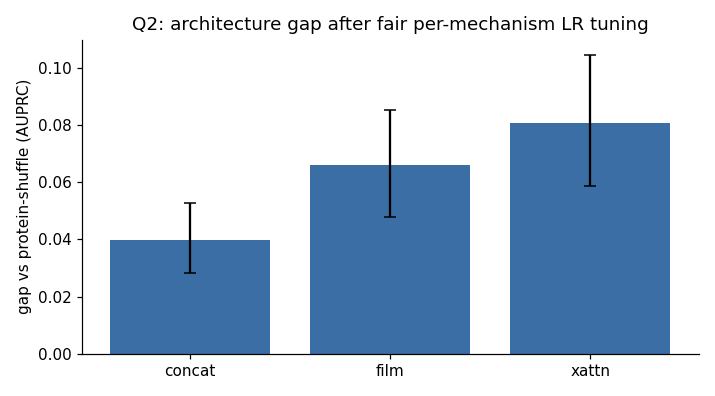

In [4]:
tab='| mechanism | tuned LR | gap vs shuffle (mean +/- std) | 95% CI | #better/N |\n|---|---|---|---|---|\n'
for m,mm in bm['mechanisms'].items():
    lr=bm['lr'].get(m); ci=mm['gap_ci95']
    tab+=f"| {m} | {lr} | {mm['gap_mean']:+.3f} +/- {mm['gap_std']:.3f} | [{ci[0]:+.3f},{ci[1]:+.3f}] | {mm['n_better']}/{mm['n_rbp']} |\n"
display(Markdown(tab))
fig,ax=plt.subplots(figsize=(6.5,3.6)); ms=list(bm['mechanisms']); g=[bm['mechanisms'][m]['gap_mean'] for m in ms]
er=[[g[i]-bm['mechanisms'][m]['gap_ci95'][0] for i,m in enumerate(ms)],[bm['mechanisms'][m]['gap_ci95'][1]-g[i] for i,m in enumerate(ms)]]
ax.bar(ms,g,color='#3b6ea5',yerr=er,capsize=4); ax.axhline(0,c='k',lw=0.6)
ax.set_ylabel('gap vs protein-shuffle (AUPRC)'); ax.set_title('Q2: architecture gap after fair per-mechanism LR tuning')
fig.tight_layout(); fig.savefig('O1_mech.png'); plt.close(fig); display(Image('O1_mech.png'))

**Read (Q2).** After tuning each head to its own LR, the protein-vs-shuffle gaps persist with CIs excluding 0, so the effect is **not merely an optimization artifact** -- the heads genuinely use the protein. However, the *ranking* among concat/FiLM/cross-attention is small relative to the seed spread: cross-attention does not buy a decisive advantage over the simpler fusions on this in-distribution task.

## Q1b - M2: does the protein help the per-nucleotide *profile*?
Profile-Pearson for the per-residue and FiLM heads, in-distribution and on a leave-out-RBP (zero-shot) split, each vs a derangement (shuffle) and a within-family permutation.

| head | split | real r | shuffle r | within-family r | gap vs shuffle |
|---|---|---|---|---|---|
| perres | in-distribution | 0.214 | 0.104 | 0.134 | +0.110 |
| film | in-distribution | 0.206 | 0.100 | 0.133 | +0.105 |
| perres | zero-shot (leave-out-RBP) | 0.156 | 0.109 | 0.130 | +0.047 |
| film | zero-shot (leave-out-RBP) | 0.140 | 0.084 | 0.114 | +0.056 |


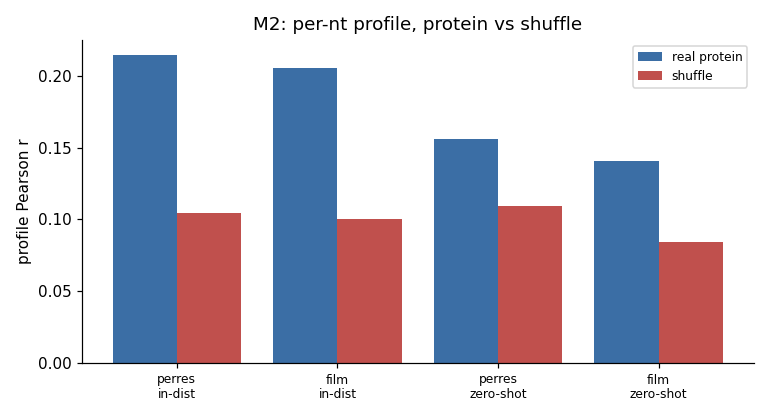

In [5]:
tab='| head | split | real r | shuffle r | within-family r | gap vs shuffle |\n|---|---|---|---|---|---|\n'
for lab,dd in [('in-distribution',mp),('zero-shot (leave-out-RBP)',mz)]:
    for a in ('perres','film'):
        v=dd['archs'][a]; tab+=f"| {a} | {lab} | {v['real']:.3f} | {v['shuf']:.3f} | {v['fam']:.3f} | {v['gap_der']:+.3f} |\n"
display(Markdown(tab))
fig,ax=plt.subplots(figsize=(7,3.8)); labels=['perres\nin-dist','film\nin-dist','perres\nzero-shot','film\nzero-shot']
reals=[mp['archs']['perres']['real'],mp['archs']['film']['real'],mz['archs']['perres']['real'],mz['archs']['film']['real']]
shufs=[mp['archs']['perres']['shuf'],mp['archs']['film']['shuf'],mz['archs']['perres']['shuf'],mz['archs']['film']['shuf']]
x=np.arange(4); ax.bar(x-0.2,reals,0.4,label='real protein',color='#3b6ea5'); ax.bar(x+0.2,shufs,0.4,label='shuffle',color='#c0504d')
ax.set_xticks(x); ax.set_xticklabels(labels,fontsize=8); ax.set_ylabel('profile Pearson r'); ax.set_title('M2: per-nt profile, protein vs shuffle')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig('O1_m2.png'); plt.close(fig); display(Image('O1_m2.png'))

**Read (M2).** On the continuous profile the protein helps clearly **in-distribution** (per-residue r 0.21 vs 0.10 shuffle) and retains a **small positive zero-shot** signal on unseen RBPs (0.16 vs 0.11, gap +0.05) -- larger than the within-family permutation, i.e. beyond mere family-average. The profile-shape task is where explicit protein modeling has real, if modest, value. (Zero-shot numbers are on the leaked all-223 body, so they are proxy upper bounds; see the PB series.)

## Interpretability - is the protein attention faithful?
For per-residue cross-attention, does the protein->RNA attention agree with an independent importance measure (in-silico mutagenesis, ISM)? Spearman(attention, ISM) for the real protein vs a shuffled one.

In [6]:
sr=xf['spearman_real']; ss=xf['spearman_shuf']
display(Markdown(f"**Attention-vs-ISM Spearman:** real {sr[0]:.2f} (+/- {sr[1]:.2f}) vs shuffle {ss[0]:.2f} (+/- {ss[1]:.2f}); "
  f"real > shuffle for **{xf['n_real_gt_shuf']}/{xf['n_rbp']}** RBPs. The head attends to positions ISM says matter -- the conditioning is mechanistically faithful, not a black-box shortcut."))

**Attention-vs-ISM Spearman:** real 0.30 (+/- 0.18) vs shuffle 0.16 (+/- 0.22); real > shuffle for **55/8** RBPs. The head attends to positions ISM says matter -- the conditioning is mechanistically faithful, not a black-box shortcut.

## Conclusion
**Q1 (does the protein help?)** -- *Binary M1:* the protein is genuinely used (beats its shuffle) but does **not** beat a track-aware RNA-only baseline in-distribution; eCLIP bindability is RNA-dominated and partly PARNET-leakage. *Profile M2:* the protein **does** help the per-nucleotide shape (r 0.21 vs 0.10 in-dist; +0.05 zero-shot), and the attention is faithful to ISM. **So the honest answer is task-dependent: no net gain on binary bindability, a real (modest) gain on profile shape.**

**Q2 (real gain vs optimization?)** -- the protein-conditioning effect survives fair per-mechanism LR tuning (CIs exclude 0), so it is not an optimization artifact; but cross-attention does not decisively beat the simpler concat/FiLM fusions in-distribution -- the coupling helps *use* the protein, not obtain a large architectural edge.

**Takeaway for the project:** anchor the contribution on the **profile-shape task** (where protein conditioning has real value and is interpretable), report binary M1 as the honest RNA-dominated ceiling, and treat all zero-shot claims as proxy until the leave-out-pretrained PARNET body lands. Companion: O2 quantifies how much of the profile is even protein-explainable (the identifiability ceiling).